# Notebook : génération de graphes pour les trois familles

Objectif : montrer que le solveur fonctionne, sur des graphes **ER**, **SP** et **Mesh**.

Ce notebook se concentre sur :
1. Génération d'une instance contrôlable (simple ou complexe).
2. Construction des vecteurs **x** (features) et **y** (décision de réparation).
3. Résolution sous contrainte de budget.
4. Visualisations lisibles + table complète de toutes les infos x et y.

## Installation

Si besoin :

`!pip install numpy networkx matplotlib scipy numba pandas`


In [45]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy.optimize import minimize

np.random.seed(42)
random.seed(42)

try:
    import pandas as pd
    PANDAS_OK = True
except Exception:
    PANDAS_OK = False

try:
    from numba import jit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False

print('Imports OK | numba:', NUMBA_OK, '| pandas:', PANDAS_OK)

Imports OK | numba: True | pandas: False


In [ ]:
# =====================================================
# 1) GENERATEURS DE GRAPHES (ER / SP / MESH)
# =====================================================

#Ne garde que les noeuds qui permettent d'atteindre la cible depuis la source
def prune_useless_nodes(G, source, target):
    try:
        reachable_from_source = set(nx.descendants(G, source)) | {source}
        can_reach_target = set(nx.ancestors(G, target)) | {target}
        useful_nodes = reachable_from_source.intersection(can_reach_target)
        return G.subgraph(useful_nodes).copy()
    except Exception:
        return G

#Graphe Erdos-Renyi orienté et construction du vecteur x des caractéristiques des noeuds
def generate_er_instance(num_nodes=10, p=0.3, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)


    while True:
        G_raw = nx.erdos_renyi_graph(n=num_nodes, p=p, directed=True)
        nodes = list(G_raw.nodes())
        if len(nodes) < 3:
            continue

        source_node, target_node = random.sample(nodes, 2)
        if nx.has_path(G_raw, source_node, target_node):
            dist = nx.shortest_path_length(G_raw, source_node, target_node)
            if dist >= 2:
                G = prune_useless_nodes(G_raw, source_node, target_node)
                if len(G.nodes()) >= 3:
                    break

    terminals = [source_node, target_node]
    repairable_nodes = [v for v in G.nodes() if v not in terminals]

    node_features = {}
    for v in G.nodes():
        is_source = 1 if v == source_node else 0
        is_target = 1 if v == target_node else 0

        if v in terminals:
            p_fail, c_cost = 0.0, 0.0
        else:
            p_fail = round(random.uniform(0.12, 0.24), 3)
            c_cost = round(random.uniform(1.0, 10.0), 2)

        try:
            dist_to_target = nx.shortest_path_length(G, source=v, target=target_node)
        except nx.NetworkXNoPath:
            dist_to_target = 999

        node_features[v] = {
            'p_fail': p_fail,
            'c_cost': c_cost,
            'is_source': is_source,
            'is_target': is_target,
            'in_degree': G.in_degree(v),
            'out_degree': G.out_degree(v),
            'distance_to_target': dist_to_target
        }

    record = {
        'topology': f'erdos_renyi_{len(G.nodes())}_nodes_p{p}',
        'graph': {
            'nodes': list(G.nodes()),
            'edges': list(G.edges()),
            'is_directed': True
        },
        'terminals': terminals,
        'repairable_nodes': repairable_nodes,
        'features': node_features
    }
    return G, record

#Graphe en série-parallèle orienté 
def generate_sp_instance(num_repairable=10, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    G = nx.DiGraph()
    source_node = 0
    target_node = 1
    G.add_edge(source_node, target_node)

    current_node_id = 2
    while current_node_id < num_repairable + 2:
        u, v = random.choice(list(G.edges()))
        operation = random.random()

        #Construction aléatoire du graphe avec une alternance : série, parallèle, boucle
        if operation < 0.4:
            G.remove_edge(u, v)
            G.add_edge(u, current_node_id)
            G.add_edge(current_node_id, v)
        elif operation < 0.8:
            G.add_edge(u, current_node_id)
            G.add_edge(current_node_id, v)
        else:
            G.remove_edge(u, v)
            G.add_edge(u, current_node_id)
            G.add_edge(current_node_id, v)
            potential_targets = [n for n in G.nodes() if n != current_node_id and n != u]
            if potential_targets and random.random() < 0.5:
                loop_target = random.choice(potential_targets)
                if random.random() < 0.5:
                    G.add_edge(current_node_id, loop_target)
                else:
                    G.add_edge(loop_target, current_node_id)

        current_node_id += 1

    terminals = [source_node, target_node]
    repairable_nodes = [v for v in G.nodes() if v not in terminals]

    node_features = {}
    for v in G.nodes():
        is_source = 1 if v == source_node else 0
        is_target = 1 if v == target_node else 0

        if v in terminals:
            p_fail, c_cost = 0.0, 0.0
        else:
            p_fail = round(random.uniform(0.10, 0.22), 3)
            c_cost = round(random.uniform(1.0, 10.0), 2)

        try:
            dist_to_target = nx.shortest_path_length(G, source=v, target=target_node)
        except nx.NetworkXNoPath:
            dist_to_target = 999

        node_features[v] = {
            'p_fail': p_fail,
            'c_cost': c_cost,
            'is_source': is_source,
            'is_target': is_target,
            'in_degree': G.in_degree(v),
            'out_degree': G.out_degree(v),
            'distance_to_target': dist_to_target
        }

    record = {
        'topology': f'series_parallel_{num_repairable}_nodes',
        'graph': {
            'nodes': list(G.nodes()),
            'edges': list(G.edges()),
            'is_directed': True
        },
        'terminals': terminals,
        'repairable_nodes': repairable_nodes,
        'features': node_features
    }
    return G, record

#Graphe mesh orienté
def generate_mesh_instance(m=3, n=4, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    G_grid = nx.grid_2d_graph(m, n)
    G = G_grid.to_directed()
    mapping = {node: i for i, node in enumerate(G.nodes())}
    G = nx.relabel_nodes(G, mapping)

    #La source et la cible sont toujours placés dans les coins opposés
    source_node = mapping[(0, 0)]
    target_node = mapping[(m - 1, n - 1)]
    terminals = [source_node, target_node]
    repairable_nodes = [v for v in G.nodes() if v not in terminals]

    node_features = {}
    for v in G.nodes():
        is_source = 1 if v == source_node else 0
        is_target = 1 if v == target_node else 0

        if v in terminals:
            p_fail, c_cost = 0.0, 0.0
        else:
            p_fail = round(random.uniform(0.16, 0.32), 3)
            c_cost = round(random.uniform(1.0, 10.0), 2)

        try:
            dist_to_target = nx.shortest_path_length(G, source=v, target=target_node)
        except nx.NetworkXNoPath:
            dist_to_target = 999

        node_features[v] = {
            'p_fail': p_fail,
            'c_cost': c_cost,
            'is_source': is_source,
            'is_target': is_target,
            'in_degree': G.in_degree(v),
            'out_degree': G.out_degree(v),
            'distance_to_target': dist_to_target
        }

    record = {
        'topology': f'mesh_grid_{m}x{n}',
        'graph': {
            'nodes': list(G.nodes()),
            'edges': list(G.edges()),
            'is_directed': True
        },
        'terminals': terminals,
        'repairable_nodes': repairable_nodes,
        'features': node_features
    }
    return G, record

print('Generateurs prêts')

Generateurs prêts


In [ ]:
# ========================================================================
# 2) SOLVEUR : downtime moyen (mis à jour avant il était en "mort subite")
# ========================================================================

"""
Je vous laisse vérifier le solveur qui semble bon sur les exemples suivants, j'ai ici changé la fonction
pour calculer le downtime moyen au lieu de la mort subite et j'ai aussi donné un horizon H égal pour tous
les graphes là où il était avant distribué en fonction de la complexité du graphe
"""
if NUMBA_OK:
    @jit(nopython=True)
    def int_to_bits(s, m):
        bits = np.zeros(m, dtype=np.int32)
        for i in range(m):
            bits[m - 1 - i] = (s >> i) & 1
        return bits
else:
    def int_to_bits(s, m):
        bits = np.zeros(m, dtype=np.int32)
        for i in range(m):
            bits[m - 1 - i] = (s >> i) & 1
        return bits

def phi_terminal_connectivity(G_res, terminals):
    source = terminals[0]
    target = terminals[-1]
    if source not in G_res or target not in G_res:
        return 0
    try:
        return 1 if nx.has_path(G_res, source, target) else 0
    except nx.NetworkXNoPath:
        return 0

def get_fail_mask(G, terminals, criterion, params):
    m = len(params['repairable_nodes'])
    S = 1 << m
    fail_mask = np.zeros(S, dtype=bool)

    for s in range(S):
        x = int_to_bits(s, m)
        active_nodes = set(terminals)
        for i, node in enumerate(params['repairable_nodes']):
            if x[i] == 1:
                active_nodes.add(node)

        G_res = G.subgraph(active_nodes)
        if criterion == 'terminal_connectivity':
            is_up = phi_terminal_connectivity(G_res, terminals)
        else:
            is_up = 1
        fail_mask[s] = (is_up == 0)

    return fail_mask

def build_transition_matrix(p_fail, r_repair):
    m = len(p_fail)
    S = 1 << m
    all_bits = np.array([[(s >> (m - 1 - i)) & 1 for i in range(m)] for s in range(S)])

    p1 = np.where(all_bits == 1, 1.0 - p_fail, r_repair)
    p0 = 1.0 - p1

    P = np.zeros((S, S), dtype=float)
    for s in range(S):
        probs_y = np.where(all_bits == 1, p1[s], p0[s])
        P[s] = np.prod(probs_y, axis=1)

    rs = P.sum(axis=1, keepdims=True)
    P = np.divide(P, rs, out=np.zeros_like(P), where=rs != 0)
    zero_rows = (rs.flatten() == 0)
    P[zero_rows, zero_rows] = 1.0
    return P

def compute_expected_downtime(P, fail_mask, H):
    S = P.shape[0]
    pi_t = np.zeros(S)
    pi_t[-1] = 1.0  # etat initial : tous les reparables UP
    total_downtime = 0.0

    for _ in range(H):
        pi_t = pi_t @ P
        total_downtime += np.sum(pi_t[fail_mask])

    return total_downtime / H

def compute_objective_J(G, terminals, criterion, params, pi, H, fail_mask=None):
    if fail_mask is None:
        fail_mask = get_fail_mask(G, terminals, criterion, params)
    P = build_transition_matrix(params['p_fail'], pi)
    return compute_expected_downtime(P, fail_mask, H)

def solve_instance(G, terminals, criterion, params, H, B, iters=35):
    m = len(params['repairable_nodes'])
    c_cost = np.array(params['c_cost'])
    fail_mask = get_fail_mask(G, terminals, criterion, params)

    def objective(pi_array):
        return compute_objective_J(G, terminals, criterion, params, pi_array, H, fail_mask=fail_mask)

    budget_constraint = {'type': 'ineq', 'fun': lambda pi_array: B - np.sum(pi_array * c_cost)}
    bounds = [(0.0, 1.0) for _ in range(m)]
    pi_0 = np.full(m, min(1.0, B / (np.sum(c_cost) + 1e-9)))

    res = minimize(
        objective,
        pi_0,
        method='SLSQP',
        bounds=bounds,
        constraints=[budget_constraint],
        options={'maxiter': iters, 'ftol': 1e-6, 'disp': False}
    )

    pi_opt = res.x
    J_star = float(res.fun)
    pi_by_node = {params['repairable_nodes'][i]: float(pi_opt[i]) for i in range(len(pi_opt))}
    for t in terminals:
        pi_by_node[t] = 0.0

    return pi_opt, J_star, pi_by_node

print('Solveur prêt (J* = downtime moyen)')

Solveur prêt (J* = downtime moyen)


In [ ]:
# =====================================================
# 3) OUTILS : instance, x/y, visualisation claire, MC
# =====================================================

"""Partie pour :
- les visualisations qui suivent
- la validation de J* à travers une simulation de Monte-Carlo. Impossible pour l'instant de vérifier la répartition du budget.
- des outils pour donner un budget adapté à chaque instance 
"""

X_COLUMNS = [
    'p_fail',
    'c_cost',
    'is_source',
    'is_target',
    'in_degree',
    'out_degree',
    'distance_to_target',
    'B',
    'H'
 ]

def record_to_graph(record):
    ginfo = record['graph']
    G = nx.DiGraph() if ginfo.get('is_directed', True) else nx.Graph()
    G.add_nodes_from(ginfo['nodes'])
    G.add_edges_from(ginfo['edges'])
    return G

def get_layout(record, G):
    topo = record.get('topology', '')
    if topo.startswith('mesh_grid_'):
        # Layout grille lisible pour les mesh
        dims = topo.replace('mesh_grid_', '').split('x')
        if len(dims) == 2 and dims[0].isdigit() and dims[1].isdigit():
            m, n = int(dims[0]), int(dims[1])
            nodes = sorted(G.nodes())
            pos = {}
            for i, node in enumerate(nodes):
                row = i // n
                col = i % n
                pos[node] = (col * 2.0, -row * 2.0)
            return pos
    # SP/ER: meilleur compromis stabilite/lisibilite
    return nx.kamada_kawai_layout(G)

def record_to_solver_params(record):
    rep = record['repairable_nodes']
    p_fail = np.array([record['features'][n]['p_fail'] for n in rep], dtype=float)
    c_cost = np.array([record['features'][n]['c_cost'] for n in rep], dtype=float)
    return {'p_fail': p_fail, 'c_cost': c_cost, 'repairable_nodes': rep}

def _solve_with_ratio(record, H, budget_ratio, iters=35):
    G = record_to_graph(record)
    terminals = record['terminals']
    params = record_to_solver_params(record)
    total_cost = float(np.sum(params['c_cost']))
    B = round(max(0.0, budget_ratio * total_cost), 4)

    pi_star, J_star, pi_by_node = solve_instance(
        G=G,
        terminals=terminals,
        criterion='terminal_connectivity',
        params=params,
        H=H,
        B=B,
        iters=iters
    )

    spent = float(np.sum(np.array(params['c_cost']) * np.array(pi_star)))
    return {
        'B': B,
        'H': H,
        'J_star': float(J_star),
        'pi_star': pi_star,
        'pi_by_node': pi_by_node,
        'spent': spent,
        'total_repairable_cost': total_cost,
        'budget_ratio': float(budget_ratio)
    }

def get_budget_alpha_risk_aware(record, graph_type):
    rep = record['repairable_nodes']
    mean_p_fail = float(np.mean([record['features'][v]['p_fail'] for v in rep])) if rep else 0.0

    if graph_type == 'mesh':
        mu, sigma, ref_p = 0.58, 0.16, 0.17
    elif graph_type == 'sp':
        mu, sigma, ref_p = 0.30, 0.10, 0.12
    else:
        mu, sigma, ref_p = 0.34, 0.11, 0.13

    risk_boost = 1.0 + 0.9 * (mean_p_fail - ref_p)
    risk_boost = float(np.clip(risk_boost, 0.85, 1.15))

    if graph_type == 'mesh':
        u_low, u_high = 0.20, 0.85
        a_low, a_high = 0.12, 0.90
    elif graph_type == 'sp':
        u_low, u_high = 0.08, 0.55
        a_low, a_high = 0.06, 0.60
    else:
        u_low, u_high = 0.10, 0.62
        a_low, a_high = 0.07, 0.68

    if random.random() < 0.70:
        alpha = np.random.normal(loc=mu, scale=sigma)
    else:
        alpha = np.random.uniform(u_low, u_high)

    alpha *= risk_boost
    return float(np.clip(alpha, a_low, a_high))

def solve_with_random_alpha(record, H=20, iters=35, graph_type='er'):
    G = record_to_graph(record)
    terminals = record['terminals']
    params = record_to_solver_params(record)
    total_cost = float(np.sum(params['c_cost']))

    alpha = get_budget_alpha_risk_aware(record, graph_type=graph_type)
    B = round(max(0.0, alpha * total_cost), 4)

    pi_star, J_star, pi_by_node = solve_instance(
        G=G,
        terminals=terminals,
        criterion='terminal_connectivity',
        params=params,
        H=H,
        B=B,
        iters=iters
    )

    spent = float(np.sum(np.array(params['c_cost']) * np.array(pi_star)))
    return {
        'B': B,
        'H': H,
        'J_star': float(J_star),
        'pi_star': pi_star,
        'pi_by_node': pi_by_node,
        'spent': spent,
        'total_repairable_cost': total_cost,
        'budget_ratio': float(B / total_cost) if total_cost > 0 else 0.0,
        'alpha': float(alpha)
    }

def calibrate_budget_ratio(record, H=20, target_j=0.5, iters=35, ratio_low=0.02, ratio_high=1.00, steps=10):
    # Hypothese pratique: quand le budget augmente, J* tend a diminuer.
    low = float(ratio_low)
    high = float(ratio_high)
    best = None
    trace = []

    out_low = _solve_with_ratio(record, H, low, iters=iters)
    out_high = _solve_with_ratio(record, H, high, iters=iters)
    trace.extend([out_low, out_high])
    best = min([out_low, out_high], key=lambda o: abs(o['J_star'] - target_j))

    for _ in range(steps):
        mid = 0.5 * (low + high)
        out_mid = _solve_with_ratio(record, H, mid, iters=iters)
        trace.append(out_mid)

        if abs(out_mid['J_star'] - target_j) < abs(best['J_star'] - target_j):
            best = out_mid

        if out_mid['J_star'] > target_j:
            # J trop grand => budget trop faible
            low = mid
        else:
            # J trop petit => budget trop fort
            high = mid

    best['target_j'] = float(target_j)
    best['calibration_trace'] = [
        {'budget_ratio': float(o['budget_ratio']), 'B': float(o['B']), 'J_star': float(o['J_star'])}
        for o in trace
    ]
    return best

def solve_record(
    record,
    H=20,
    budget_ratio=0.6,
    iters=35,
    budget_mode='random_risk',
    target_j=0.5,
    ratio_low=0.02,
    ratio_high=1.00,
    calib_steps=10,
    graph_type='er',
 ):
    if budget_mode == 'target_j':
        return calibrate_budget_ratio(
            record,
            H=H,
            target_j=target_j,
            iters=iters,
            ratio_low=ratio_low,
            ratio_high=ratio_high,
            steps=calib_steps,
        )
    if budget_mode == 'random_risk':
        return solve_with_random_alpha(record, H=H, iters=iters, graph_type=graph_type)
    return _solve_with_ratio(record, H=H, budget_ratio=budget_ratio, iters=iters)

def build_xy_rows(record, solve_out):
    nodes = sorted(record['graph']['nodes'])
    terminals = set(record['terminals'])
    rows = []

    for n in nodes:
        f = record['features'][n]
        y_pi = 0.0 if n in terminals else float(solve_out['pi_by_node'][n])
        row = {
            'node': int(n),
            'p_fail': float(f['p_fail']),
            'c_cost': float(f['c_cost']),
            'is_source': float(f['is_source']),
            'is_target': float(f['is_target']),
            'in_degree': float(f['in_degree']),
            'out_degree': float(f['out_degree']),
            'distance_to_target': float(f['distance_to_target']),
            'B': float(solve_out['B']),
            'H': float(solve_out['H']),
            'y_pi': y_pi,
            'budget_contrib': float(f['c_cost']) * y_pi
        }
        row['node_type'] = 'source' if row['is_source'] == 1 else ('target' if row['is_target'] == 1 else 'repairable')
        rows.append(row)

    return rows

def rows_to_dataframe(rows):
    if not PANDAS_OK:
        return None
    cols = ['node'] + X_COLUMNS + ['y_pi', 'budget_contrib', 'node_type']
    return pd.DataFrame(rows)[cols]

def fast_is_connected(G_base, source, target, up_nodes):
    valid_nodes = set(up_nodes) | {source, target}
    subG = G_base.subgraph(valid_nodes)
    try:
        return nx.has_path(subG, source, target)
    except nx.NetworkXPointlessConcept:
        return False

def simulate_monte_carlo_downtime(record, rows, n_sims=3000):
    H = int(rows[0]['H']) if rows else 1
    nodes = sorted(record['graph']['nodes'])
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    terminals = record['terminals']
    source, target = terminals[0], terminals[1]
    rep_nodes = [n for n in nodes if n not in terminals]

    p_fail = np.array([rows[node_to_idx[n]]['p_fail'] for n in rep_nodes], dtype=float)
    pi_star = np.array([rows[node_to_idx[n]]['y_pi'] for n in rep_nodes], dtype=float)

    G = record_to_graph(record)
    states = np.ones((n_sims, len(rep_nodes)), dtype=bool)
    downtime_counts = np.zeros(n_sims, dtype=float)

    for _ in range(H):
        rands = np.random.rand(n_sims, len(rep_nodes))
        to_down = states & (rands < p_fail)
        to_up = (~states) & (rands < pi_star)
        states = (states & ~to_down) | to_up

        for idx in range(n_sims):
            up_rep_nodes = [rep_nodes[i] for i, is_up in enumerate(states[idx]) if is_up]
            if not fast_is_connected(G, source, target, up_rep_nodes):
                downtime_counts[idx] += 1.0

    return float(np.mean(downtime_counts) / H)

def budget_report(rows, solve_out, j_mc=None):
    budget = float(solve_out['B'])
    spent = float(sum(r['budget_contrib'] for r in rows))
    util = 100.0 * spent / budget if budget > 1e-12 else 0.0
    print(f"B (budget max)              : {budget:.4f}")
    print(f"Somme c_i * y_i (utilisee)   : {spent:.4f}")
    print(f"Utilisation budget           : {util:.2f}%")
    print(f"Ratio budget/total cout      : {solve_out.get('budget_ratio', float('nan')):.4f}")
    if 'target_j' in solve_out:
        print(f"Cible J*                     : {solve_out['target_j']:.4f}")
    print(f"J* solveur (downtime moyen)  : {solve_out['J_star']:.6f}")
    if j_mc is not None:
        print(f"J* Monte-Carlo (meme def.)   : {j_mc:.6f}")
        print(f"Erreur absolue |MC - J*|     : {abs(j_mc - solve_out['J_star']):.6f}")

def _external_label_positions(pos, x_shift=0.45, y_jitter=0.0):
    label_pos = {}
    for i, (node, (x, y)) in enumerate(pos.items()):
        label_pos[node] = (x + x_shift, y + (i % 2) * y_jitter - ((i + 1) % 2) * y_jitter)
    return label_pos

def draw_clean_pair(record, rows, solve_out, title_prefix=''):
    G = record_to_graph(record)
    pos = get_layout(record, G)
    nodes = sorted(G.nodes())
    terminals = set(record['terminals'])

    risk_map = {r['node']: r['p_fail'] for r in rows}
    pi_map = {r['node']: r['y_pi'] for r in rows}
    cost_map = {r['node']: r['c_cost'] for r in rows}
    type_map = {r['node']: r['node_type'] for r in rows}

    budget = float(solve_out['B'])
    spent = float(sum(r['budget_contrib'] for r in rows))
    spent_pct = 100.0 * spent / budget if budget > 1e-12 else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    plt.subplots_adjust(wspace=0.10)

    for ax, mode in zip(axes, ['risk', 'budget']):
        ax.set_axis_off()
        nx.draw_networkx_edges(
            G, pos, ax=ax, arrowstyle='-|>', arrowsize=16,
            edge_color='#666666', alpha=0.45, width=2.0, connectionstyle='arc3,rad=0.08'
        )

        nodelist_rep = [n for n in nodes if n not in terminals]
        nodelist_term = [n for n in nodes if n in terminals]

        if mode == 'risk':
            vals = [risk_map[n] for n in nodelist_rep]
            cmap = cm.YlOrRd
            norm = colors.Normalize(vmin=0.0, vmax=max(0.15, max(vals) if vals else 0.15))
            rep_colors = [cmap(norm(v)) for v in vals]
            title = 'Etat brut: p_fail'
            bar_label = 'p_fail'
        else:
            vals = [pi_map[n] for n in nodelist_rep]
            cmap = cm.Blues
            norm = colors.Normalize(vmin=0.0, vmax=1.0)
            rep_colors = [cmap(norm(v)) for v in vals]
            title = 'Solution ideale: y_i = pi_i'
            bar_label = 'y_i'

        rep_sizes = [700 for _ in nodelist_rep]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodelist_rep, node_color=rep_colors, node_size=rep_sizes,
            edgecolors='#003366', linewidths=2.0, ax=ax
        )

        term_colors = ['#00DD00' if n == record['terminals'][0] else '#FF0000' for n in nodelist_term]
        term_edges = ['#005500' if n == record['terminals'][0] else '#660000' for n in nodelist_term]
        for n, c, ec in zip(nodelist_term, term_colors, term_edges):
            nx.draw_networkx_nodes(
                G, pos, nodelist=[n], node_color=c, node_size=1050,
                edgecolors=ec, linewidths=2.6, ax=ax
            )

        nx.draw_networkx_labels(
            G, pos, labels={n: str(n) for n in nodes}, font_size=9,
            font_weight='bold', font_color='white', ax=ax
        )

        label_pos = _external_label_positions(pos, x_shift=0.55, y_jitter=0.16)
        ext_labels = {}
        for n in nodes:
            if type_map[n] == 'source':
                ext_labels[n] = f'SOURCE\\nnode={n}'
            elif type_map[n] == 'target':
                ext_labels[n] = f'TARGET\\nnode={n}'
            elif mode == 'risk':
                ext_labels[n] = f"p={risk_map[n]:.2f} | c={cost_map[n]:.2f}"
            else:
                ext_labels[n] = f"y={pi_map[n]:.2f} | c={cost_map[n]:.2f}"

        for n in nodes:
            x0, y0 = pos[n]
            x1, y1 = label_pos[n]
            ax.plot([x0, x1], [y0, y1], color='#888888', linewidth=0.8, alpha=0.85)
            ax.text(
                x1, y1, ext_labels[n], fontsize=8, va='center', ha='left', color='#222222',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='#BBBBBB', alpha=0.92)
            )

        ax.set_title(title, fontsize=12, fontweight='bold')
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.01)
        cbar.set_label(bar_label, fontsize=9)

        info_text = f"{len(nodes)} noeuds | {len(G.edges())} aretes | source={record['terminals'][0]} | target={record['terminals'][1]}"
        ax.text(0.5, -0.08, info_text, transform=ax.transAxes, fontsize=9, ha='center', color='#444444')

        if mode == 'budget':
            ax.text(
                0.02, 0.98,
                f"Budget depense: {spent_pct:.1f}%\\n({spent:.2f} / {budget:.2f})",
                transform=ax.transAxes, va='top', ha='left', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#888888', alpha=0.95)
            )

    fig.suptitle(
        f"{title_prefix} | B={solve_out['B']:.2f} | H={solve_out['H']} | J*={solve_out['J_star']:.5f} | Budget depense={spent_pct:.1f}%",
        fontsize=13, fontweight='bold'
    )
    plt.show()

def show_xy_table(rows):
    cols = ['node'] + X_COLUMNS + ['y_pi', 'budget_contrib', 'node_type']
    if PANDAS_OK:
        df = rows_to_dataframe(rows)
        display(df.sort_values(['node']).reset_index(drop=True))
    else:
        print('Pandas indisponible: affichage texte complet de x/y')
        header = ' | '.join(cols)
        print(header)
        print('-' * len(header))
        for r in sorted(rows, key=lambda z: z['node']):
            values = [str(r[c]) for c in cols]
            print(' | '.join(values))

def run_family_instance(
    family='er',
    shape=(6, 0.35),
    H=20,
    budget_ratio=0.60,
    seed=7,
    iters=35,
    n_sims_mc=2000,
    budget_mode='random_risk',
    target_j=0.5,
 ):
    if family == 'er':
        num_nodes, p = shape
        _, record = generate_er_instance(num_nodes=num_nodes, p=p, seed=seed)
    elif family == 'sp':
        num_repairable = shape[0]
        _, record = generate_sp_instance(num_repairable=num_repairable, seed=seed)
    elif family == 'mesh':
        m, n = shape
        _, record = generate_mesh_instance(m=m, n=n, seed=seed)
    else:
        raise ValueError("family doit etre 'er', 'sp' ou 'mesh'")

    solve_out = solve_record(
        record,
        H=H,
        budget_ratio=budget_ratio,
        iters=iters,
        budget_mode=budget_mode,
        target_j=target_j,
        ratio_low=0.02,
        ratio_high=1.00,
        calib_steps=10,
        graph_type=family,
    )
    rows = build_xy_rows(record, solve_out)
    j_mc = simulate_monte_carlo_downtime(record, rows, n_sims=n_sims_mc)

    print(f"Famille: {family} | Topologie: {record['topology']}")
    print(f"Noeuds: {len(record['graph']['nodes'])} | Aretes: {len(record['graph']['edges'])}")
    print(f"Terminaux (source, target): {record['terminals']}")
    budget_report(rows, solve_out, j_mc=j_mc)
    draw_clean_pair(record, rows, solve_out, title_prefix=family.upper())

    print('\\nTable complete x/y (une ligne = un noeud):')
    show_xy_table(rows)

    return record, solve_out, rows, j_mc

print('Outils solveur + visualisation prêts (budget random_risk par défaut)')

Outils solveur + visualisation prêts (budget random_risk par défaut)


## Instance ER (parametrable)

Ajustez `shape=(num_nodes, p)` pour rendre l'instance plus simple ou plus complexe.
- Exemple simple : `(5, 0.30)`
- Exemple plus dense : `(12, 0.42)`

Famille: er | Topologie: erdos_renyi_5_nodes_p0.22
Noeuds: 5 | Aretes: 9
Terminaux (source, target): [0, 5]
B (budget max)              : 10.0877
Somme c_i * y_i (utilisee)   : 10.0877
Utilisation budget           : 100.00%
Ratio budget/total cout      : 0.5441
J* solveur (downtime moyen)  : 0.139443
J* Monte-Carlo (meme def.)   : 0.140320
Erreur absolue |MC - J*|     : 0.000877


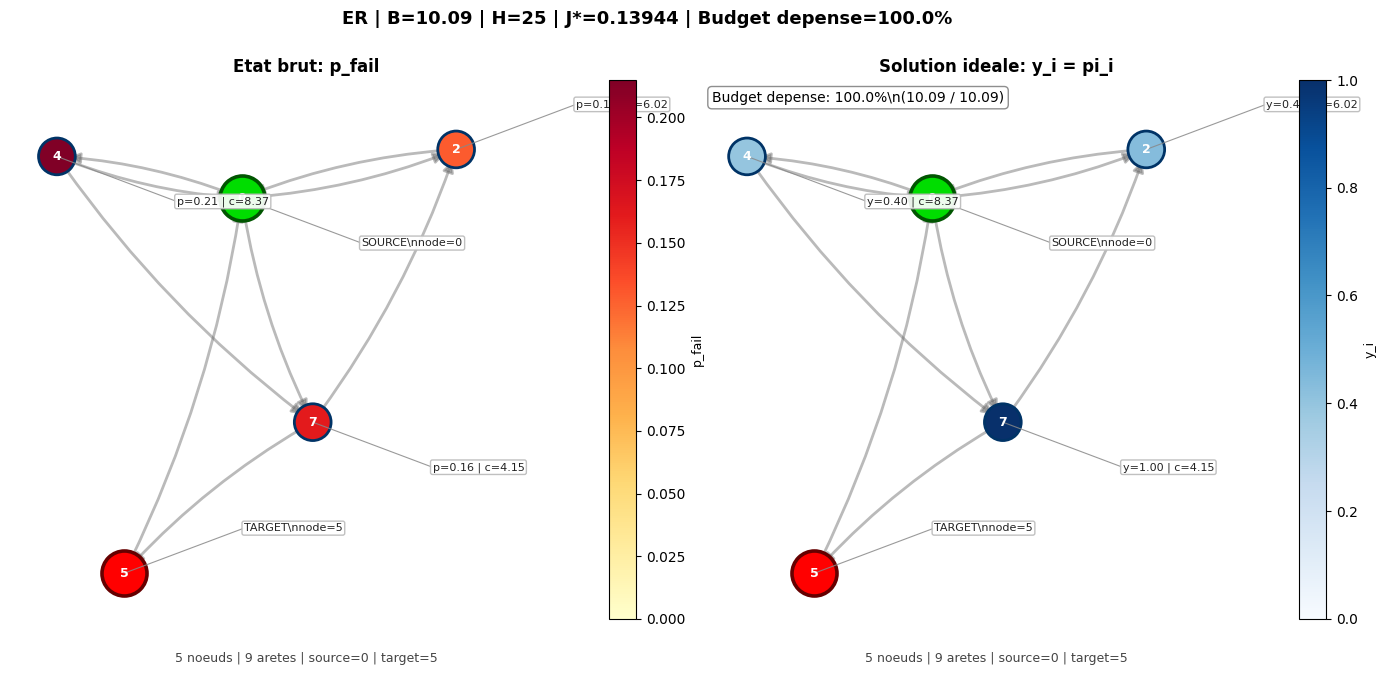

\nTable complete x/y (une ligne = un noeud):
Pandas indisponible: affichage texte complet de x/y
node | p_fail | c_cost | is_source | is_target | in_degree | out_degree | distance_to_target | B | H | y_pi | budget_contrib | node_type
----------------------------------------------------------------------------------------------------------------------------------------
0 | 0.0 | 0.0 | 1.0 | 0.0 | 3.0 | 3.0 | 2.0 | 10.0877 | 25.0 | 0.0 | 0.0 | source
2 | 0.129 | 6.02 | 0.0 | 0.0 | 2.0 | 1.0 | 3.0 | 10.0877 | 25.0 | 0.4369557707980305 | 2.6304737402041436 | repairable
4 | 0.215 | 8.37 | 0.0 | 0.0 | 1.0 | 2.0 | 2.0 | 10.0877 | 25.0 | 0.39512857623232805 | 3.3072261830645857 | repairable
5 | 0.0 | 0.0 | 0.0 | 1.0 | 1.0 | 1.0 | 0.0 | 10.0877 | 25.0 | 0.0 | 0.0 | target
7 | 0.161 | 4.15 | 0.0 | 0.0 | 2.0 | 2.0 | 1.0 | 10.0877 | 25.0 | 1.0 | 4.15 | repairable


In [82]:
rec_er, sol_er, rows_er, jmc_er = run_family_instance(
    family='er',
     shape=(8, 0.22),
    H=25,
    budget_ratio=0.55,
    seed=7,
    iters=35,
    n_sims_mc=2000,
    budget_mode='random_risk',
    target_j=0.5,
 )

## Instance SP (parametrable)

Ajuste `shape=(num_repairable,)`.
- Exemple simple : `(3,)`
- Exemple plus complexe : `(10,)`

Famille: sp | Topologie: series_parallel_7_nodes
Noeuds: 9 | Aretes: 12
Terminaux (source, target): [0, 1]
B (budget max)              : 17.5790
Somme c_i * y_i (utilisee)   : 17.5790
Utilisation budget           : 100.00%
Ratio budget/total cout      : 0.4865
J* solveur (downtime moyen)  : 0.213745
J* Monte-Carlo (meme def.)   : 0.213060
Erreur absolue |MC - J*|     : 0.000685


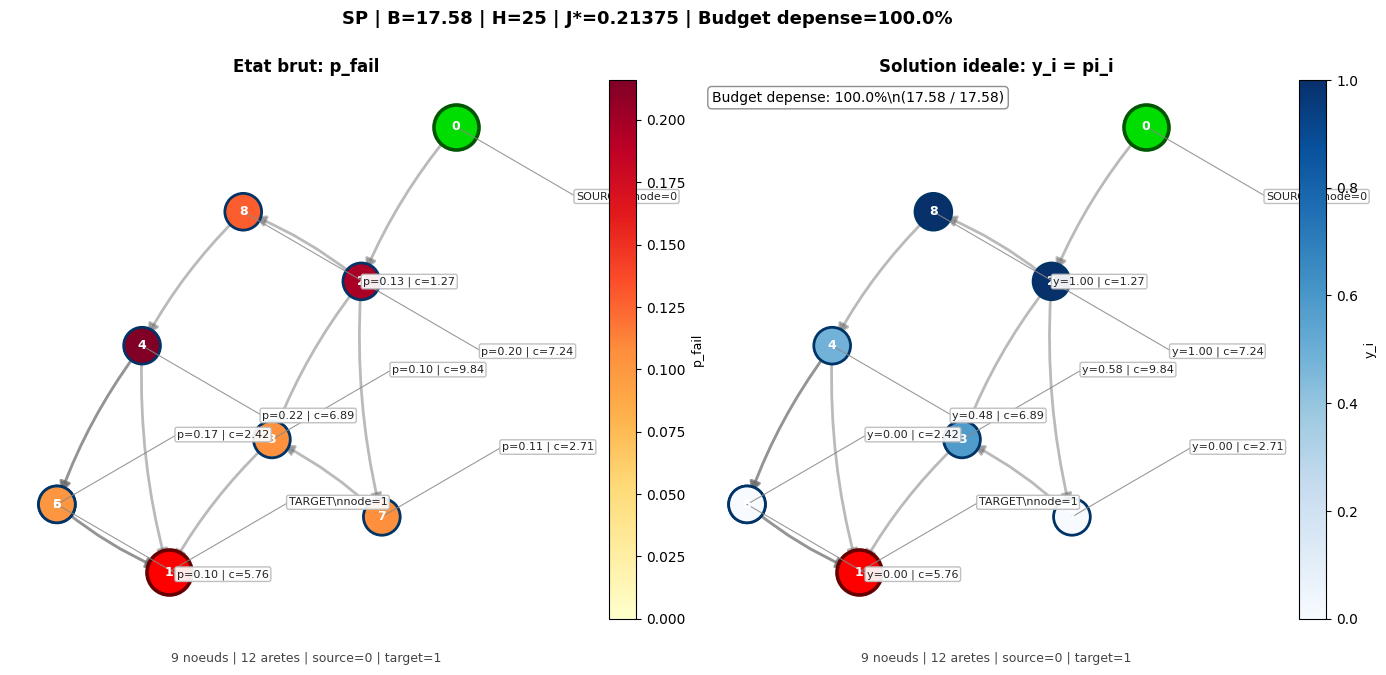

\nTable complete x/y (une ligne = un noeud):
Pandas indisponible: affichage texte complet de x/y
node | p_fail | c_cost | is_source | is_target | in_degree | out_degree | distance_to_target | B | H | y_pi | budget_contrib | node_type
----------------------------------------------------------------------------------------------------------------------------------------
0 | 0.0 | 0.0 | 1.0 | 0.0 | 0.0 | 1.0 | 3.0 | 17.579 | 25.0 | 0.0 | 0.0 | source
1 | 0.0 | 0.0 | 0.0 | 1.0 | 4.0 | 0.0 | 0.0 | 17.579 | 25.0 | 0.0 | 0.0 | target
2 | 0.197 | 7.24 | 0.0 | 0.0 | 1.0 | 3.0 | 2.0 | 17.579 | 25.0 | 0.9999999999999999 | 7.239999999999999 | repairable
3 | 0.105 | 9.84 | 0.0 | 0.0 | 2.0 | 1.0 | 1.0 | 17.579 | 25.0 | 0.5844153293177279 | 5.750646840486442 | repairable
4 | 0.216 | 6.89 | 0.0 | 0.0 | 1.0 | 3.0 | 1.0 | 17.579 | 25.0 | 0.48161874588371034 | 3.318353159138764 | repairable
5 | 0.174 | 2.42 | 0.0 | 0.0 | 1.0 | 1.0 | 1.0 | 17.579 | 25.0 | 5.199878559433316e-17 | 1.2583706113828625e-16 | r

In [83]:
rec_sp, sol_sp, rows_sp, jmc_sp = run_family_instance(
    family='sp',
    shape=(7,),
    H=25,
    budget_ratio=0.60,
    seed=11,
    iters=35,
    n_sims_mc=2000,
    budget_mode='random_risk',
    target_j=0.5,
 )

## Instance Mesh (parametrable)

Ajuste `shape=(m, n)` pour la taille de la grille.
- Exemple simple : `(2, 3)`
- Exemple plus complexe : `(4, 5)`

Famille: mesh | Topologie: mesh_grid_2x4
Noeuds: 8 | Aretes: 20
Terminaux (source, target): [0, 7]
B (budget max)              : 20.2861
Somme c_i * y_i (utilisee)   : 20.2861
Utilisation budget           : 100.00%
Ratio budget/total cout      : 0.6016
J* solveur (downtime moyen)  : 0.223152
J* Monte-Carlo (meme def.)   : 0.222140
Erreur absolue |MC - J*|     : 0.001012


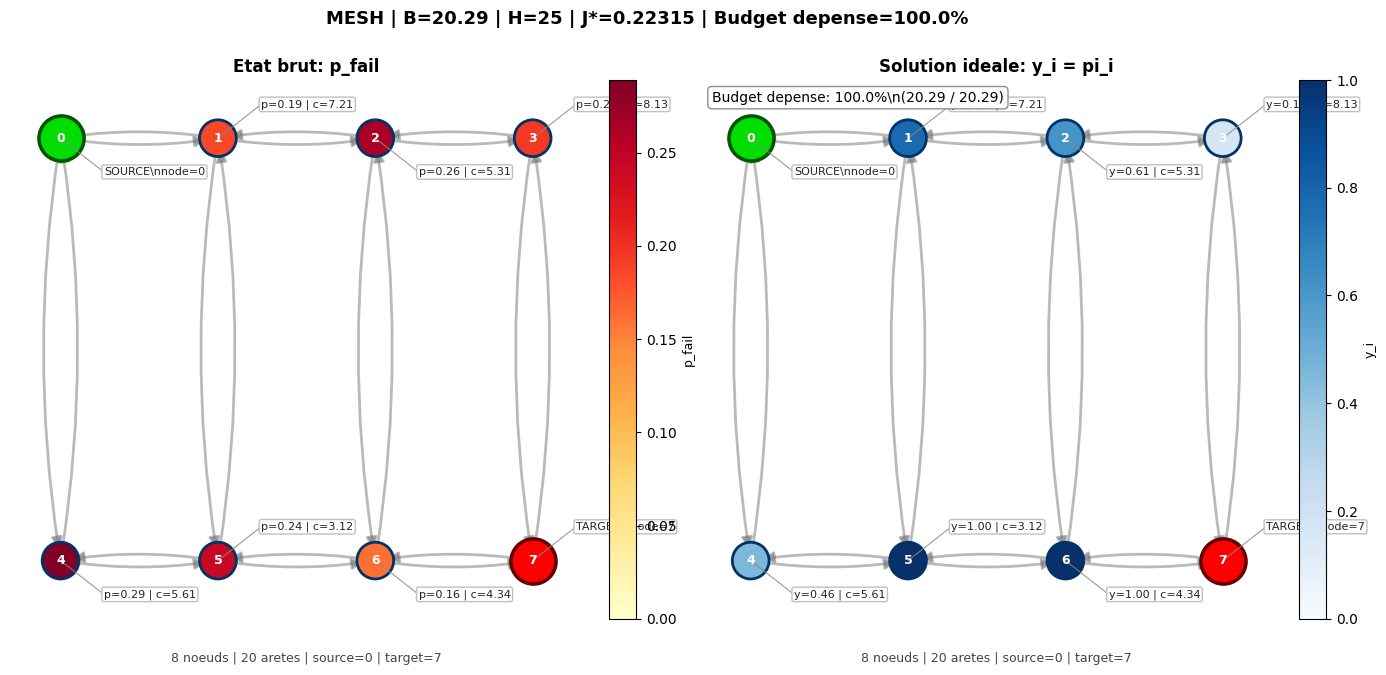

\nTable complete x/y (une ligne = un noeud):
Pandas indisponible: affichage texte complet de x/y
node | p_fail | c_cost | is_source | is_target | in_degree | out_degree | distance_to_target | B | H | y_pi | budget_contrib | node_type
----------------------------------------------------------------------------------------------------------------------------------------
0 | 0.0 | 0.0 | 1.0 | 0.0 | 2.0 | 2.0 | 4.0 | 20.2861 | 25.0 | 0.0 | 0.0 | source
1 | 0.186 | 7.21 | 0.0 | 0.0 | 3.0 | 3.0 | 3.0 | 20.2861 | 25.0 | 0.7800662052962147 | 5.624277340185708 | repairable
2 | 0.262 | 5.31 | 0.0 | 0.0 | 3.0 | 3.0 | 2.0 | 20.2861 | 25.0 | 0.6138330045255866 | 3.259453254030865 | repairable
3 | 0.195 | 8.13 | 0.0 | 0.0 | 2.0 | 2.0 | 1.0 | 20.2861 | 25.0 | 0.17094224259649082 | 1.3897604323094706 | repairable
4 | 0.289 | 5.61 | 0.0 | 0.0 | 2.0 | 2.0 | 3.0 | 20.2861 | 25.0 | 0.45501051223471417 | 2.5526089736367465 | repairable
5 | 0.241 | 3.12 | 0.0 | 0.0 | 3.0 | 3.0 | 2.0 | 20.2861 | 25.0 | 1.0 |

In [71]:
rec_mesh, sol_mesh, rows_mesh, jmc_mesh = run_family_instance(
    family='mesh',
    shape=(2, 4),
    H=25,
    budget_ratio=0.50,
    seed=21,
    iters=40,
    n_sims_mc=2000,
    budget_mode='random_risk',
    target_j=0.5,
 )

## Lecture de la repartition du budget et validation Monte-Carlo

Definition des sorties :
- Variable de decision : `y_i = pi_i in [0, 1]` pour chaque noeud reparable `i`.
- Contrainte budget : `sum_i c_i * y_i <= B`.
- Objectif : minimiser `J*`, ici defini comme le **downtime moyen** sur l'horizon `H` (fraction de temps en panne).

Budget dans ce notebook :
- Le mode actif est `budget_mode='random_risk'` (budget aléatoire orienté risque).
- Définition du budget : `B = alpha * C_total`, où `C_total` est le coût total des noeuds réparables.
- `alpha` est tiré aléatoirement selon la topologie et le risque moyen de l'instance.
- Si besoin, le mode `budget_mode='target_j'` permet encore de cibler `J* ~ 0.5`.

Dans la table affichee pour chaque famille :
- Les colonnes `p_fail, c_cost, is_source, is_target, in_degree, out_degree, distance_to_target, B, H` correspondent a `x`.
- La colonne `y_pi` correspond a `y`.
- La colonne `budget_contrib = c_cost * y_pi` montre la part de budget consommee par noeud.

Sur le schema de solution (panneau de droite), le **% de budget depense** est affiche directement.
La validation Monte-Carlo suit la meme definition de `J*` (downtime moyen).